In [60]:
import pandas as pd
from prettytable import PrettyTable

In [61]:
paris_summer = pd.read_csv("./data/medals_total.csv",encoding="utf-8")
winter_summer_games = pd.read_csv("./data/world_olympedia_olympics_game_medal_tally.csv",encoding="utf-8")

In [62]:
winter_summer_games

,year,edition,edition_id,country,country_noc,gold,silver,bronze,total
0,1896,1896 Summer Olympics,1,Greece,GRE,10,18,19,47
1,1900,1900 Summer Olympics,2,France,FRA,31,41,40,112
2,1900,1900 Summer Olympics,2,United States,USA,20,13,15,48
3,1904,1904 Summer Olympics,3,United States,USA,80,85,83,248
4,1908,1908 Summer Olympics,5,Great Britain,GBR,56,51,39,146
...,...,...,...,...,...,...,...,...,...
1802,2008,2008 Summer Olympics,53,Australia,AUS,14,15,17,46
1803,2008,2008 Summer Olympics,53,Cuba,CUB,3,10,17,30
1804,2012,2012 Summer Olympics,54,Japan,JPN,7,14,17,38
1805,2016,2016 Summer Olympics,59,Great Britain,GBR,27,23,17,67


In [63]:
paris_summer

,country_code,country,country_long,Gold Medal,Silver Medal,Bronze Medal,Total
0,USA,United States,United States of America,40,44,42,126
1,CHN,China,People's Republic of China,40,27,24,91
2,JPN,Japan,Japan,20,12,13,45
3,AUS,Australia,Australia,18,19,16,53
4,FRA,France,France,16,26,22,64
...,...,...,...,...,...,...,...
87,PER,Peru,Peru,0,0,1,1
88,QAT,Qatar,Qatar,0,0,1,1
89,SGP,Singapore,Singapore,0,0,1,1
90,SVK,Slovakia,Slovakia,0,0,1,1


In [64]:
paris_summer_processed = (
    paris_summer
    .rename(columns={
    "country_code": "country_noc",
    "Gold Medal": "gold",
    "Silver Medal": "silver",
    "Bronze Medal": "bronze",
    "Total": "total"
    })
)

paris_summer_processed = paris_summer_processed.groupby("country")[["gold","silver","bronze","total"]].sum()

In [65]:
paris_summer_processed

,gold,silver,bronze,total
country,,,,
AIN,1,3,1,5
Albania,0,0,2,2
Algeria,2,0,1,3
Argentina,1,1,1,3
Armenia,0,3,1,4
...,...,...,...,...
Uganda,1,1,0,2
Ukraine,3,5,4,12
United States,40,44,42,126


In [66]:
paris_summer_processed.reset_index(inplace=True)

In [67]:
winter_summer_games

,year,edition,edition_id,country,country_noc,gold,silver,bronze,total
0,1896,1896 Summer Olympics,1,Greece,GRE,10,18,19,47
1,1900,1900 Summer Olympics,2,France,FRA,31,41,40,112
2,1900,1900 Summer Olympics,2,United States,USA,20,13,15,48
3,1904,1904 Summer Olympics,3,United States,USA,80,85,83,248
4,1908,1908 Summer Olympics,5,Great Britain,GBR,56,51,39,146
...,...,...,...,...,...,...,...,...,...
1802,2008,2008 Summer Olympics,53,Australia,AUS,14,15,17,46
1803,2008,2008 Summer Olympics,53,Cuba,CUB,3,10,17,30
1804,2012,2012 Summer Olympics,54,Japan,JPN,7,14,17,38
1805,2016,2016 Summer Olympics,59,Great Britain,GBR,27,23,17,67


In [68]:
# Separar por jogos de verão/inverno
summer = winter_summer_games[winter_summer_games["edition"].str.contains("Summer")]
winter = winter_summer_games[winter_summer_games["edition"].str.contains("Winter")]

summer = pd.concat([summer, paris_summer_processed])

summer_medals = summer.groupby("country")["total"].sum()
winter_medals = winter.groupby("country")["total"].sum()

In [69]:
summer

,year,edition,edition_id,country,country_noc,gold,silver,bronze,total
0,1896.0,1896 Summer Olympics,1.0,Greece,GRE,10,18,19,47
1,1900.0,1900 Summer Olympics,2.0,France,FRA,31,41,40,112
2,1900.0,1900 Summer Olympics,2.0,United States,USA,20,13,15,48
3,1904.0,1904 Summer Olympics,3.0,United States,USA,80,85,83,248
4,1908.0,1908 Summer Olympics,5.0,Great Britain,GBR,56,51,39,146
...,...,...,...,...,...,...,...,...,...
87,NaN,NaN,NaN,Uganda,NaN,1,1,0,2
88,NaN,NaN,NaN,Ukraine,NaN,3,5,4,12
89,NaN,NaN,NaN,United States,NaN,40,44,42,126
90,NaN,NaN,NaN,Uzbekistan,NaN,8,2,3,13


In [70]:
summer_medals

country
AIN                         5
Afghanistan                 2
Albania                     2
Algeria                    20
Argentina                  80
                         ... 
West Germany              204
West Indies Federation      2
Yugoslavia                 83
Zambia                      3
Zimbabwe                    8
Name: total, Length: 163, dtype: int64

In [71]:
summer

,year,edition,edition_id,country,country_noc,gold,silver,bronze,total
0,1896.0,1896 Summer Olympics,1.0,Greece,GRE,10,18,19,47
1,1900.0,1900 Summer Olympics,2.0,France,FRA,31,41,40,112
2,1900.0,1900 Summer Olympics,2.0,United States,USA,20,13,15,48
3,1904.0,1904 Summer Olympics,3.0,United States,USA,80,85,83,248
4,1908.0,1908 Summer Olympics,5.0,Great Britain,GBR,56,51,39,146
...,...,...,...,...,...,...,...,...,...
87,NaN,NaN,NaN,Uganda,NaN,1,1,0,2
88,NaN,NaN,NaN,Ukraine,NaN,3,5,4,12
89,NaN,NaN,NaN,United States,NaN,40,44,42,126
90,NaN,NaN,NaN,Uzbekistan,NaN,8,2,3,13


In [72]:
summer_medals = summer_medals.sort_values(ascending=False)
winter_medals = winter_medals.sort_values(ascending=False)

In [73]:
print("Summer medals:")
print(summer_medals)

print("\nWinter medals:")
print(winter_medals)

Summer medals:
country
United States                   2781
Soviet Union                    1010
Great Britain                    992
France                           837
Germany                          824
                                ... 
Sudan                              1
Turkmenistan                       1
Tonga                              1
Togo                               1
United States Virgin Islands       1
Name: total, Length: 163, dtype: int64

Winter medals:
country
Norway                                   405
United States                            330
Germany                                  286
Austria                                  250
Canada                                   225
Soviet Union                             194
Sweden                                   176
Finland                                  175
Switzerland                              168
Netherlands                              147
Italy                                    141
France      

In [74]:
summer_medals = (
    summer.groupby("country")[["gold","silver","bronze","total"]]
    .sum()
    .sort_values("total", ascending=False)
)

winter_medals = (
    winter.groupby("country")[["gold","silver","bronze","total"]]
    .sum()
    .sort_values("total", ascending=False)
)

total_medals = (
    winter_summer_games.groupby("country")[["gold","silver","bronze","total"]]
    .sum()
    .sort_values("total", ascending=False)
)


In [75]:
summer_medals.columns
winter_medals.columns
total_medals.columns

Index(['gold', 'silver', 'bronze', 'total'], dtype='str')

In [76]:
def dataframe_to_prettytable(df, title):
    table = PrettyTable()
    table.title = title
    table.field_names = ["Country", "Gold", "Silver", "Bronze", "Total"]

    for country, row in df.iterrows():
        table.add_row([country, row["gold"], row["silver"], row["bronze"], row["total"]])

    print(table)

In [77]:
dataframe_to_prettytable(summer_medals, "Medalhas – Jogos de Verão")

+------------------------------------------------------------------------+
|                       Medalhas – Jogos de Verão                        |
+---------------------------------------+------+--------+--------+-------+
|                Country                | Gold | Silver | Bronze | Total |
+---------------------------------------+------+--------+--------+-------+
|             United States             | 1110 |  885   |  786   |  2781 |
|              Soviet Union             | 395  |  319   |  296   |  1010 |
|             Great Britain             | 305  |  345   |  342   |  992  |
|                 France                | 247  |  283   |  307   |  837  |
|                Germany                | 249  |  277   |  298   |  824  |
|                 Italy                 | 234  |  206   |  229   |  669  |
|       People's Republic of China      | 263  |  199   |  174   |  636  |
|               Australia               | 180  |  189   |  225   |  594  |
|                 Japan  

In [78]:
dataframe_to_prettytable(winter_medals, "Medalhas – Jogos de Inverno")

+------------------------------------------------------------------------+
|                      Medalhas – Jogos de Inverno                       |
+---------------------------------------+------+--------+--------+-------+
|                Country                | Gold | Silver | Bronze | Total |
+---------------------------------------+------+--------+--------+-------+
|                 Norway                | 148  |  134   |  123   |  405  |
|             United States             | 113  |  122   |   95   |  330  |
|                Germany                | 112  |  104   |   70   |  286  |
|                Austria                |  71  |   88   |   91   |  250  |
|                 Canada                |  77  |   72   |   76   |  225  |
|              Soviet Union             |  78  |   57   |   59   |  194  |
|                 Sweden                |  65  |   51   |   60   |  176  |
|                Finland                |  45  |   65   |   65   |  175  |
|              Switzerlan

In [79]:
dataframe_to_prettytable(total_medals, "Medalhas – Total Geral")

+------------------------------------------------------------------------+
|                         Medalhas – Total Geral                         |
+---------------------------------------+------+--------+--------+-------+
|                Country                | Gold | Silver | Bronze | Total |
+---------------------------------------+------+--------+--------+-------+
|             United States             | 1195 |  969   |  845   |  3009 |
|              Soviet Union             | 473  |  376   |  355   |  1204 |
|                Germany                | 355  |  377   |  366   |  1098 |
|             Great Britain             | 312  |  339   |  337   |  988  |
|                 France                | 287  |  308   |  356   |  951  |
|                 Italy                 | 271  |  244   |  274   |  789  |
|       People's Republic of China      | 285  |  231   |  197   |  713  |
|                 Sweden                | 216  |  233   |  248   |  697  |
|                 Japan  

In [80]:
import matplotlib.pyplot as plt

In [81]:
def criar_grafico_50_top(data,string):
    plt.figure(figsize=(10,20))
    plt.barh(data.index, data["total"])
    plt.gca().invert_yaxis()
    plt.xlabel("Total de Medalhas")
    plt.title("Top 50 Países com Mais Medalhas Olímpicas em "+string)

    plt.tight_layout()
    plt.show()

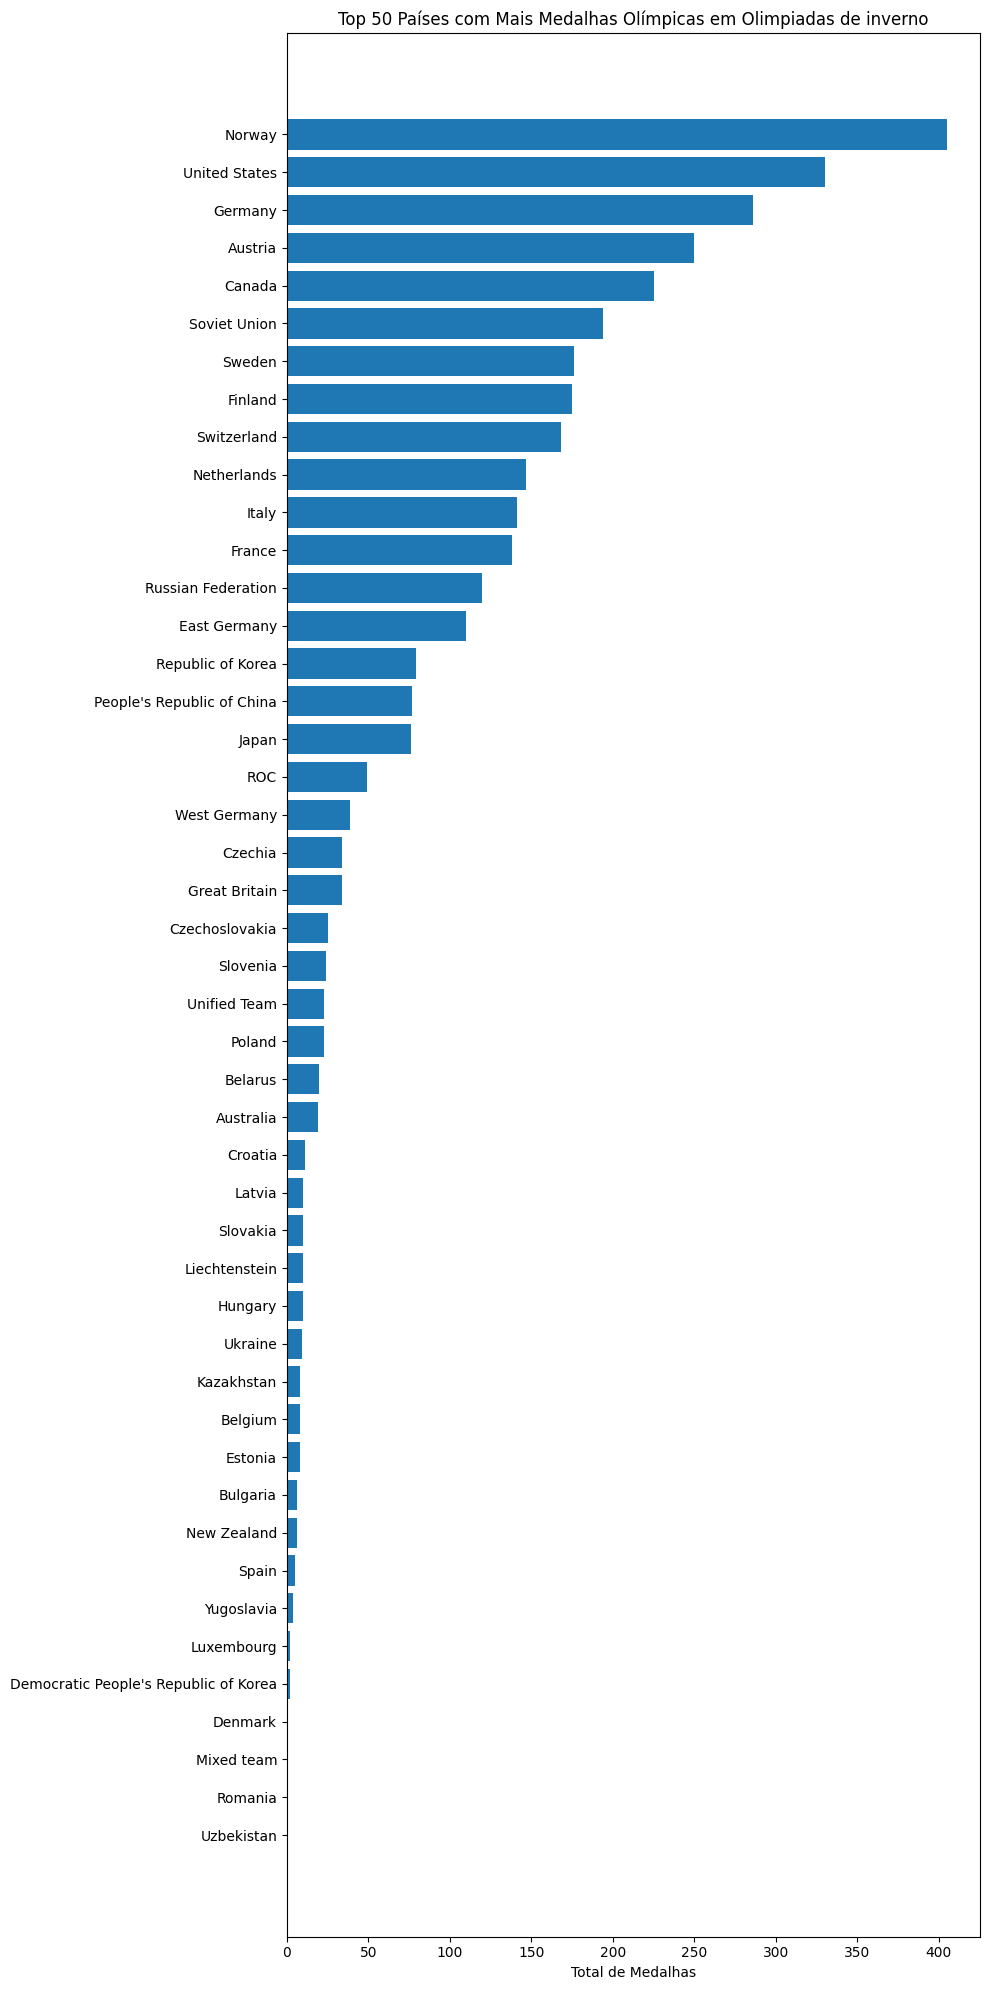

In [82]:
criar_grafico_50_top(winter_medals,"Olimpiadas de inverno")

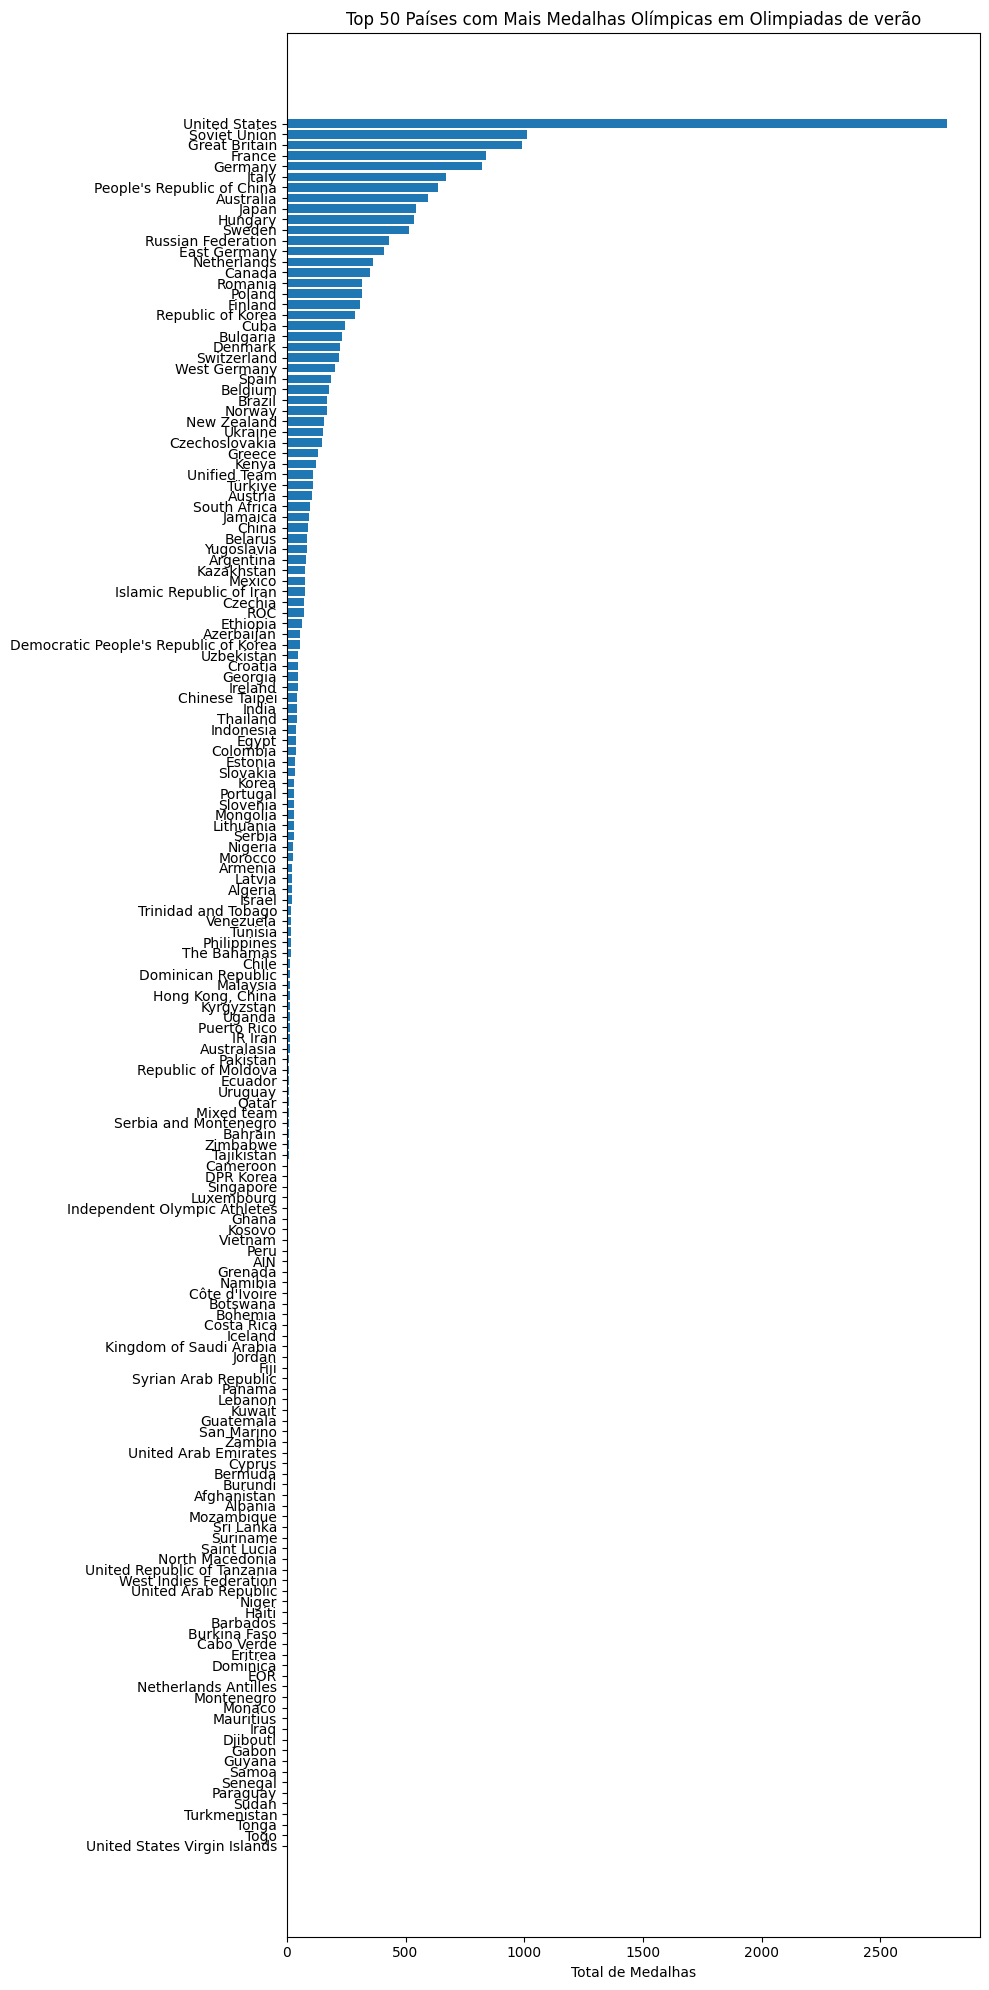

In [83]:
criar_grafico_50_top(summer_medals,"Olimpiadas de verão")

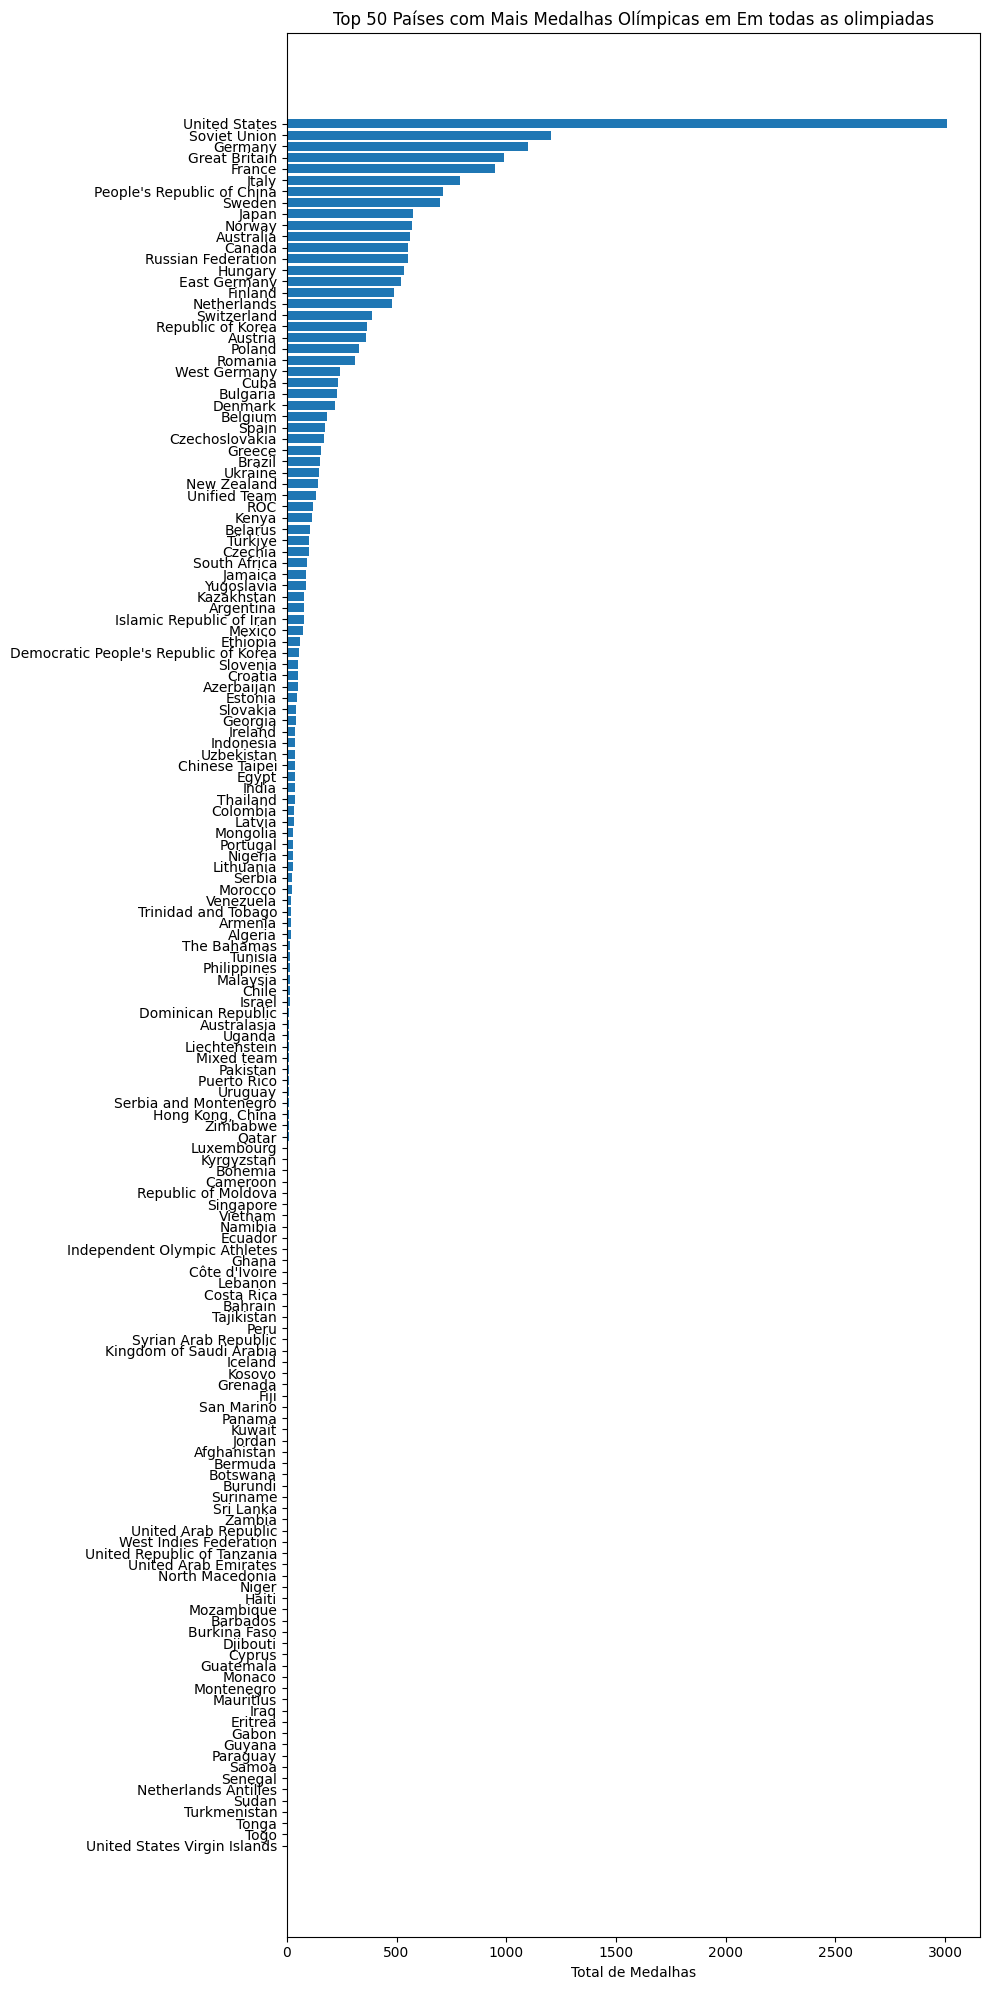

In [84]:
criar_grafico_50_top(total_medals,"Em todas as olimpiadas")